In [2]:

import os
import glob
import pandas as pd
import numpy as np
import scanpy as sc
import anndata as ad
import scipy.sparse as sp  
from scipy.sparse import csr_matrix
from scipy.io import mmread


import matplotlib.pyplot as plt
import seaborn as sns

os.chdir("/data/scottaa/cta_onco_fetal")

In [ ]:
adata_fetal = sc.read_h5ad("datasets/fetal_gonad/working_adata/fetal_gonad_Female_annotated.h5ad")
adata_embryo = sc.read_h5ad("datasets/embryos_mixed/working_adata/embryos_mixed_female_processed_annotated.h5ad")

['Proliferating', 'Stromal', 'Mixed', 'Endothelial', 'RA–responsive germ cells', 'Perivascular', 'Immune', 'Epithelial', 'Meiotic germ cells', 'Oocytes', 'Early somatic']


/data/scottaa/conda/envs/rnaseq-pipe/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/tmp/ipykernel_1444475/2980490114.py:2: FutureWarning: Categorical.to_list is deprecated and will be removed in a future version. Use obj.tolist() instead
  print(adata_fetal.obs["celltype_leiden_res_2.0"].unique().to_list())


# Cell Markers

/data/scottaa/conda/envs/rnaseq-pipe/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


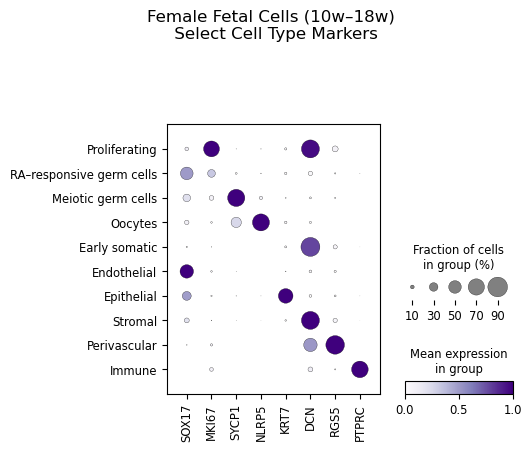

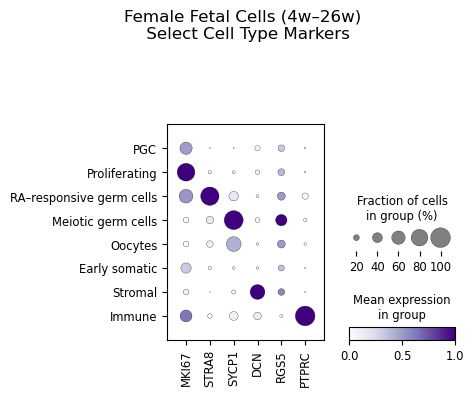

In [177]:
genes_all = [
    "SOX17",   # early germline / PGC
    "MKI67",   # proliferating
    "STRA8",   # RA-responsive
    "SYCP1",   # meiotic
    "NLRP5",   # oocyte
    "KRT7",    # epithelial
    "DCN",     # stromal
    "RGS5",    # perivascular
    "PTPRC"    # immune

]

cell_type_order_all = ["PGC",
    "Proliferating",
    "RA–responsive germ cells",
    "Meiotic germ cells",
    "Oocytes",
    "Early somatic",
    "Endothelial",
    "Epithelial",
    "Stromal",
    "Perivascular",
    
    
    
    "Immune"
]

adata_plot_fetal = adata_fetal[~adata_fetal.obs["celltype_leiden_res_2.0"].isin(["Mixed"])].copy()
genes_fetal = [g for g in genes_all if g in adata_plot_fetal.var_names]
cell_type_order_fetal = [ct for ct in cell_type_order_all if ct in adata_plot_fetal.obs["celltype_leiden_res_2.0"].unique()]

sc.pl.dotplot(adata_plot_fetal, var_names=genes_fetal,groupby="celltype_leiden_res_2.0", categories_order=cell_type_order_fetal, standard_scale="var", cmap="Purples",
              title="Female Fetal Cells (10w–18w) \n Select Cell Type Markers",
              save="fetal_gonad_female_markers.png")

adata_plot_embryos = adata_embryos[~adata_embryos.obs["celltype_leiden_res_2.0"].isin(["Mixed", "Ribosomal", "Ambiguous", "Late germline"])].copy()
genes_embryos = [g for g in genes_all if g in adata_plot_embryos.var_names]
cell_type_order_embryos = [ct for ct in cell_type_order_all if ct in adata_plot_embryos.obs["celltype_leiden_res_2.0"].unique()]

sc.pl.dotplot(adata_plot_embryos, var_names=genes_embryos,groupby="celltype_leiden_res_2.0", categories_order=cell_type_order_embryos, standard_scale="var", cmap="Purples",
              title="Female Fetal Cells (4w–26w) \n Select Cell Type Markers",
              save="embryos_mixed_female_markers.png")

# Clustermap

In [ ]:

cell_type_order = ['PGC', 'RA–responsive germ cells','Meiotic germ cells','Oocytes','Proliferating', 'Early somatic','Stromal','Endothelial','Epithelial','Immune', 'Ribosomal', 'Ambiguous', 'Unknown', 'Mixed' ]

fetal_gonad_frac_df = pd.read_csv("datasets/fetal_gonad/results/tables/cta_analysis/fetal_gonad_Female_cta_fraction_expression.csv", index_col = 0)
embryos_mixed_frac_df = pd.read_csv("datasets/embryos_mixed/results/tables/cta_analysis/embryos_mixed_female_cta_fraction_expression.csv", index_col = 0)

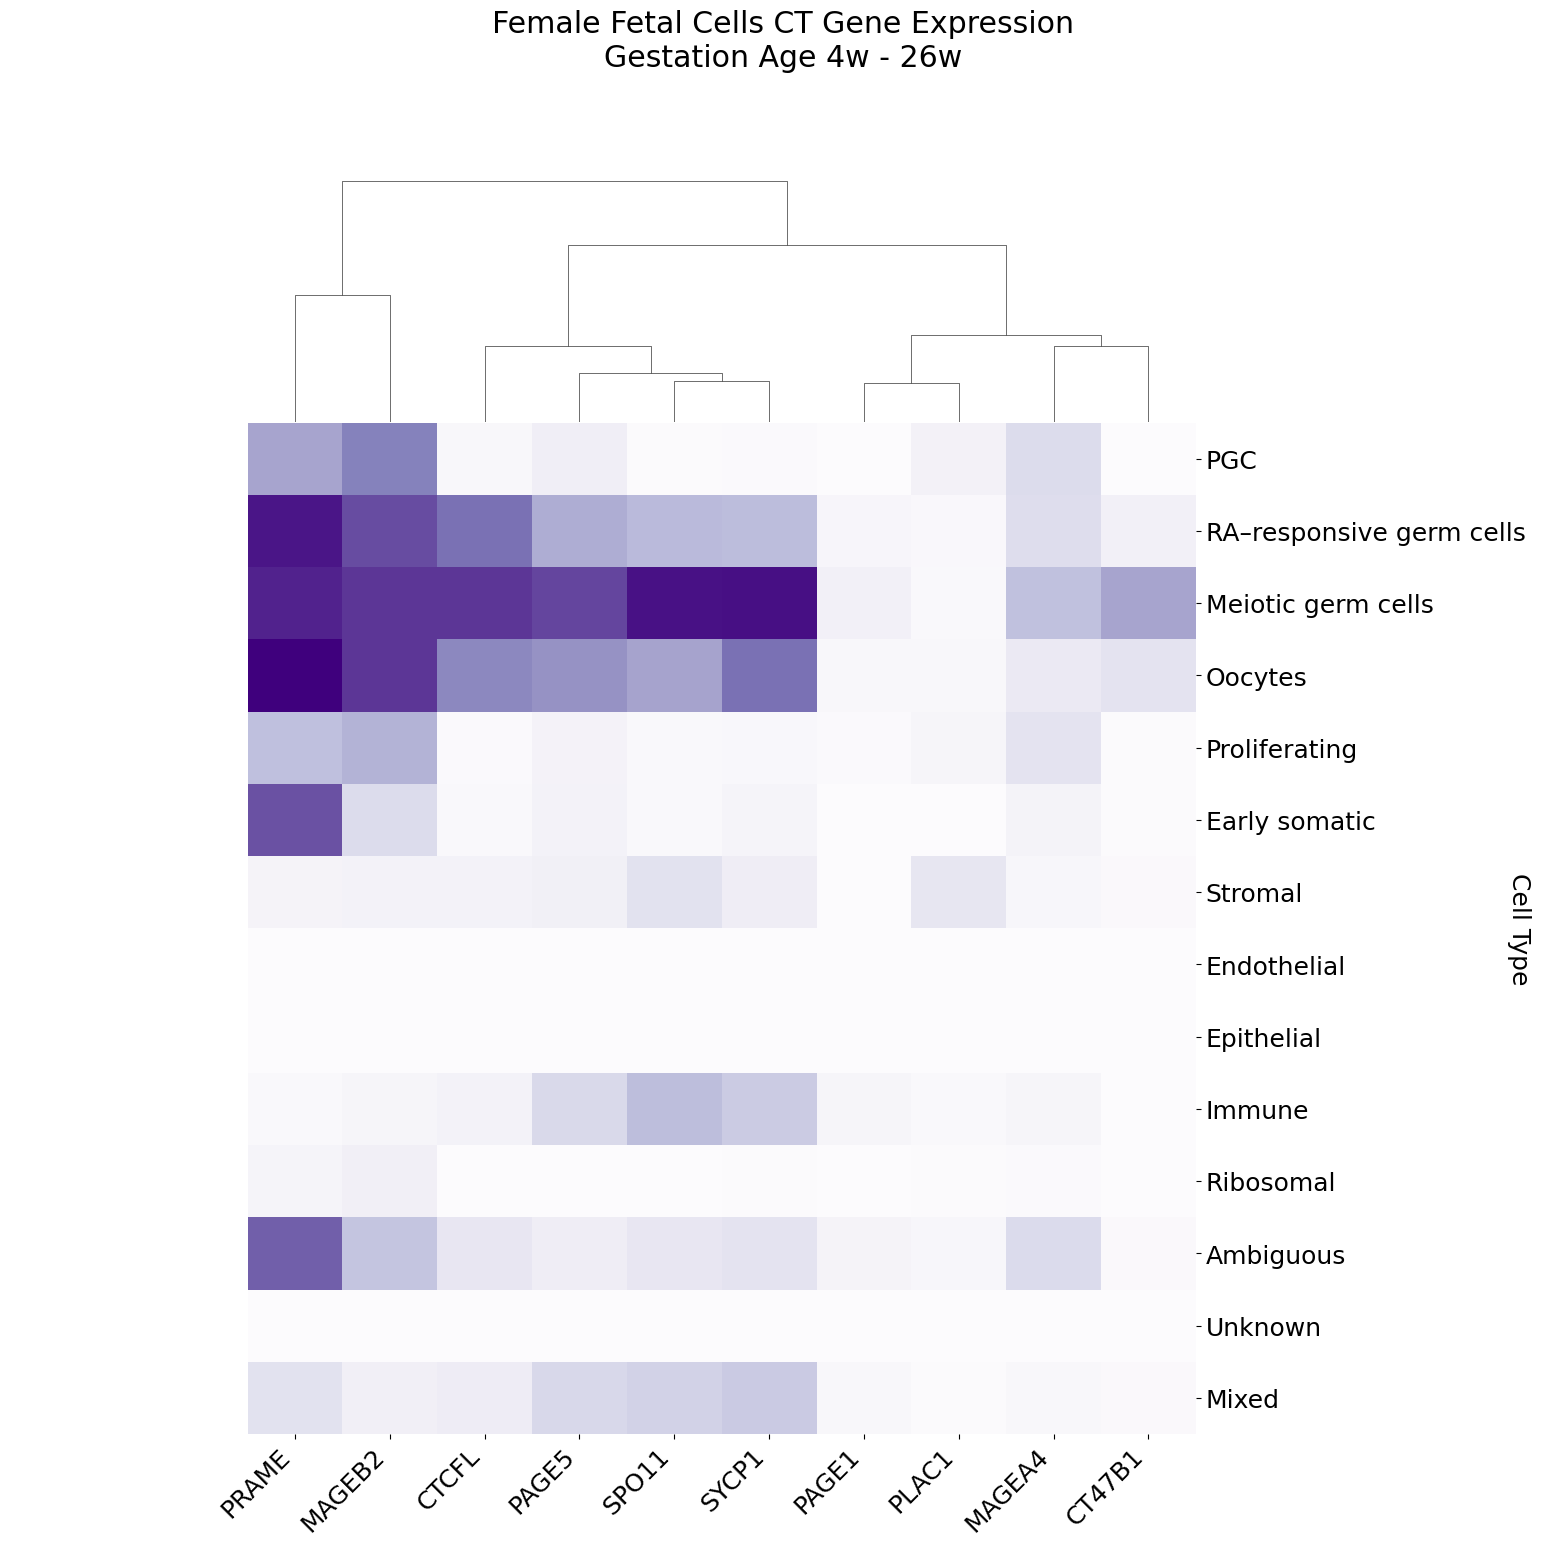

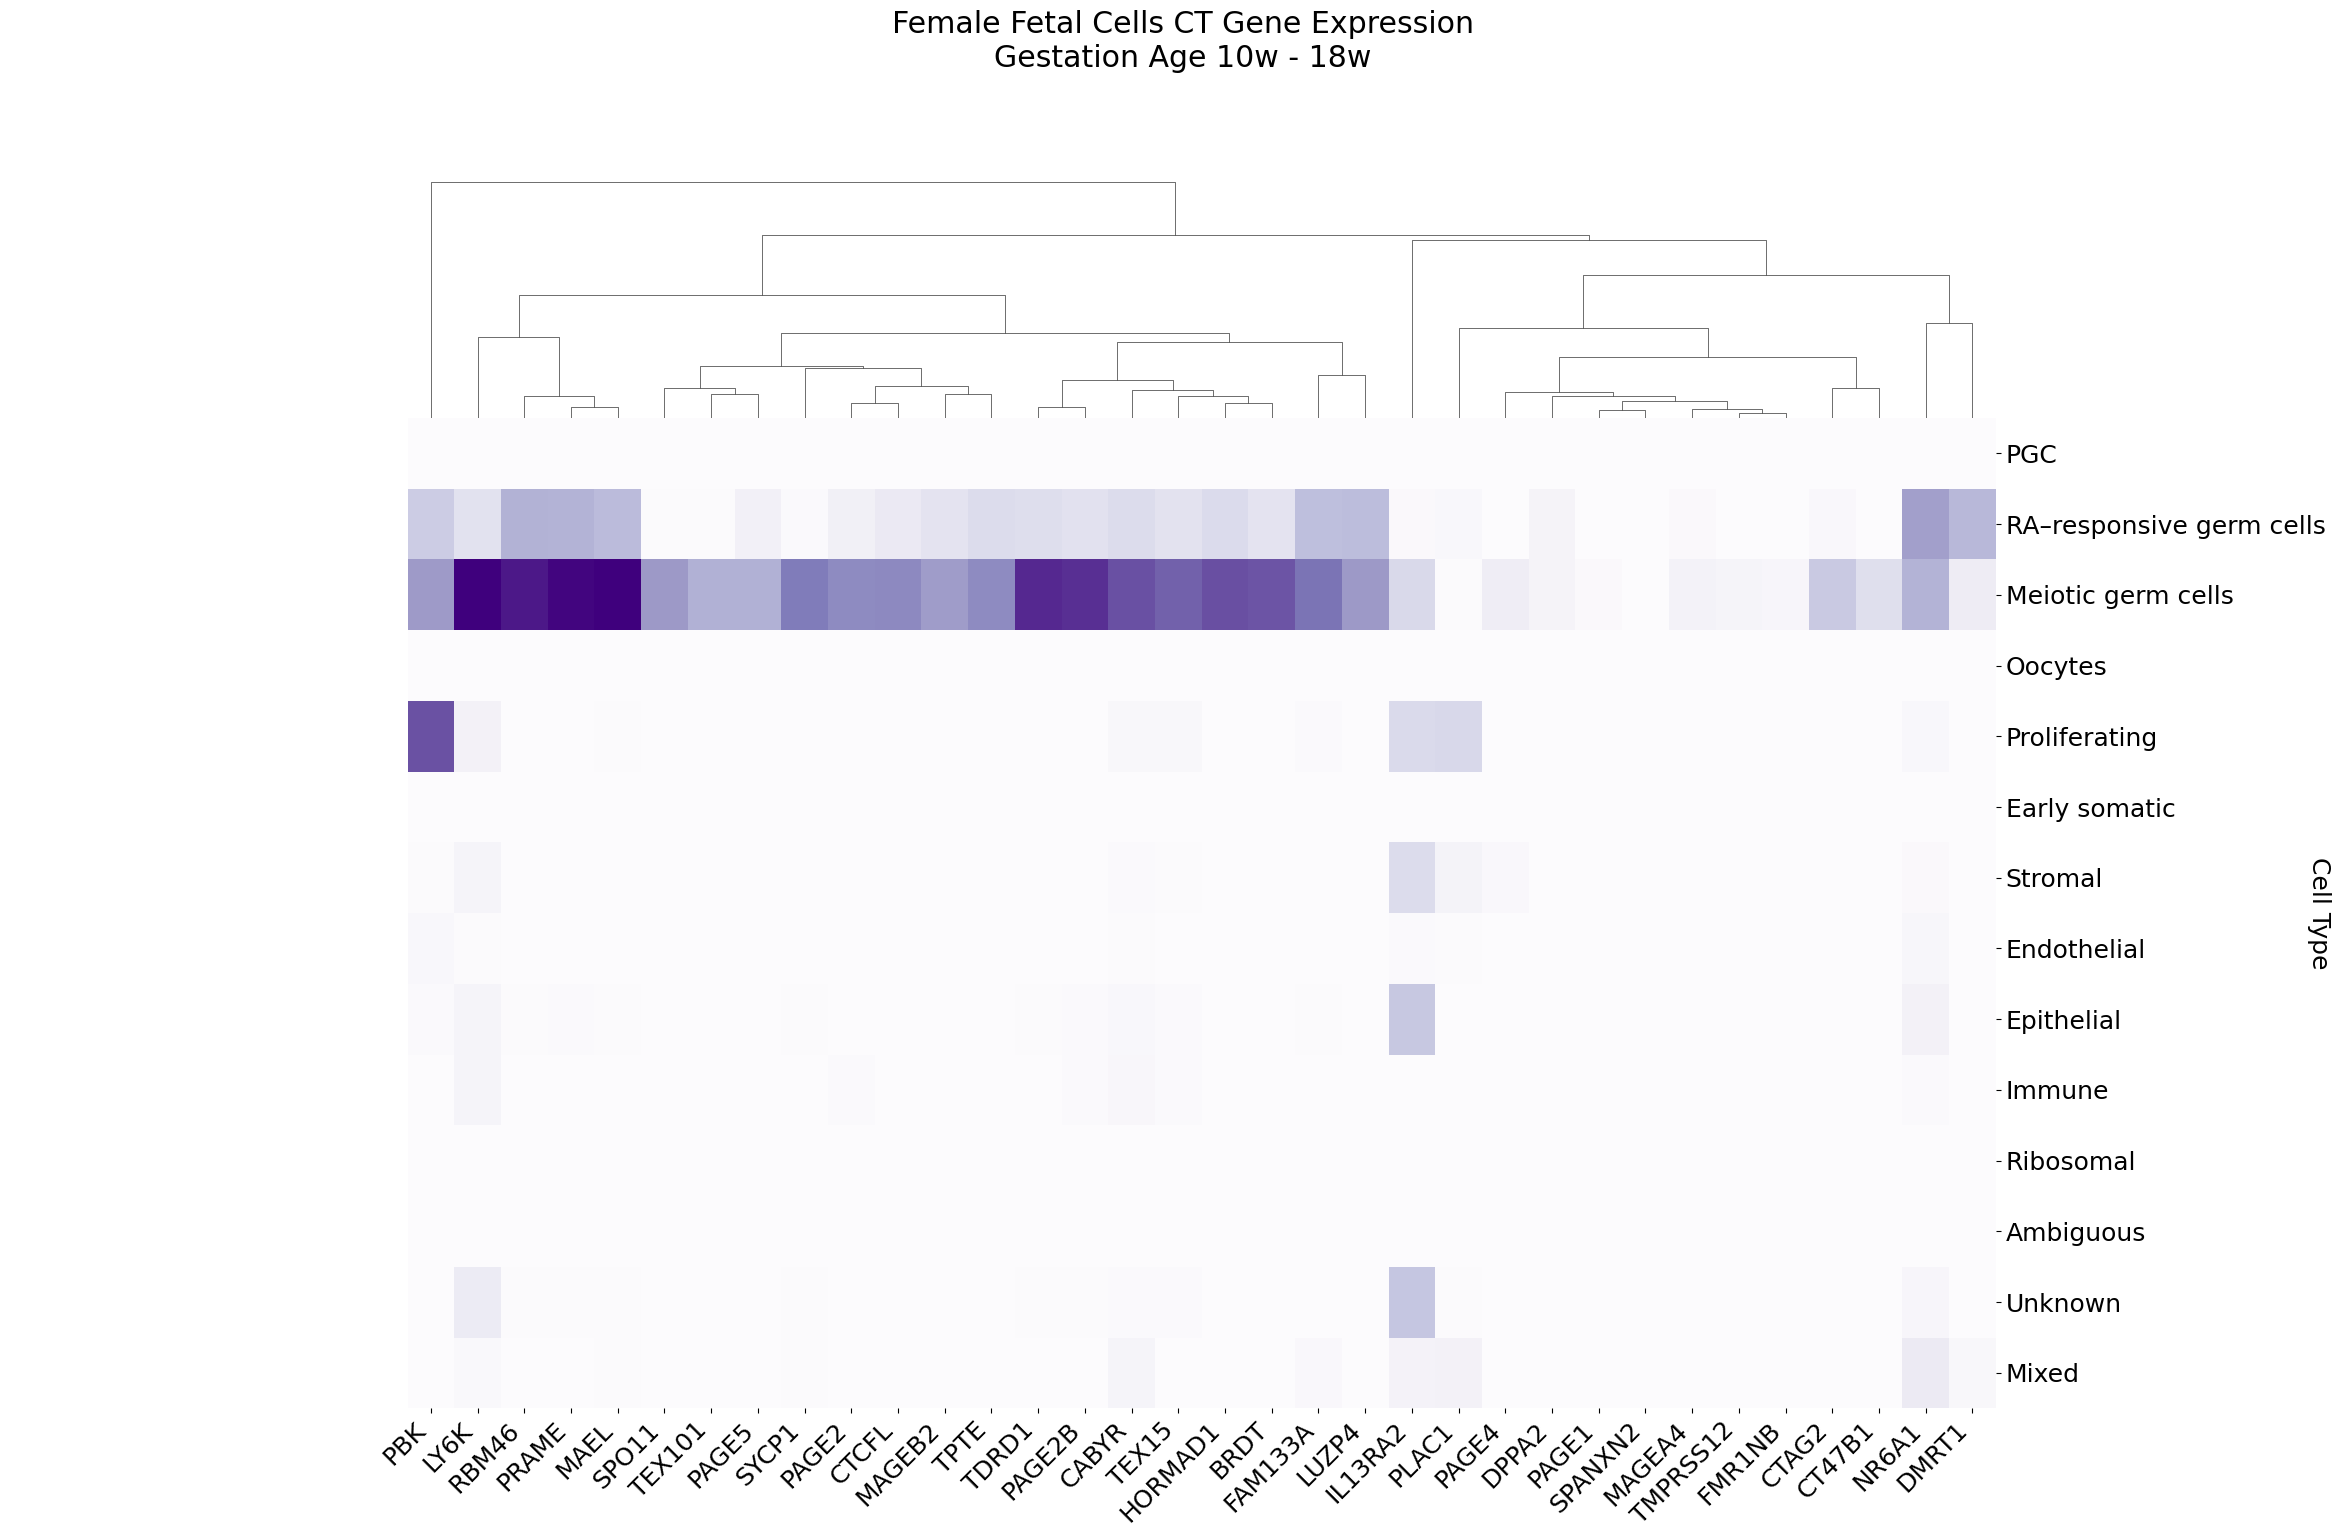

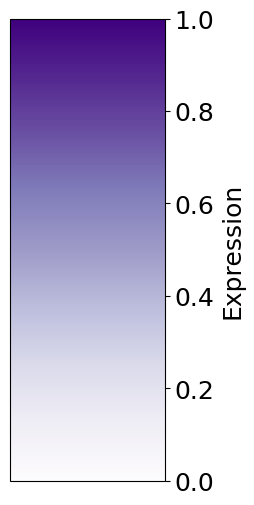

In [73]:


all_cell_types = list(set(list(fetal_gonad_frac_df.index) + list(embryos_mixed_frac_df.index)))
all_genes = list(set(list(fetal_gonad_frac_df.columns) + list(embryos_mixed_frac_df.columns)))
gene_order = [

    # Early germ cell / pluripotency
    "PRDM14", "DPPA2", "NR6A1",

    # PGC / early germline
    "PRAME", "FAM133A",

    # Meiosis initiation / recombination
    "SPO11", "SYCP1", "HORMAD1", "HORMAD2",

    # Meiotic / germline machinery
    "TDRD1", "TDRD6", "MAEL", "TEX15", "RBM46", "MORC1",

    # Late germline / spermatogenic
    "TEX101", "TMPRSS12", "DMRT1", "BRDT",

    # Cancer-testis antigens (classic CTGs)
    "MAGEA4", "MAGEB2", "MAGEC2",
    "PAGE1", "PAGE2", "PAGE2B", "PAGE4", "PAGE5",
    "CTAG2", "CT47B1", "CTCFL",

    # Other CTGs / miscellaneous
    "CABYR", "SPANXN2", "LY6K", "TPTE", "PBK", "PLAC1",
    "IL13RA2", "LUZP4", "FMR1NB"
]

##################################





df_fetal = fetal_gonad_frac_df.reindex(cell_type_order).fillna(0)
gene_order = [g for g in gene_order if g in df_fetal.columns]
df_fetal = df_fetal[gene_order]
df_embryo = embryos_mixed_frac_df.reindex(cell_type_order).fillna(0)
gene_order = [g for g in gene_order if g in df_embryo.columns]
df_embryo = df_embryo[gene_order]

# Set global font size using rcParams
plt.rcParams['font.size'] = 18




plt.rcParams['font.size'] = 18

g = sns.clustermap(df_embryo, row_cluster=False, col_cluster=True, cmap="Purples", cbar_pos=None, figsize=(16, 16))
g.fig.suptitle("Female Fetal Cells CT Gene Expression\nGestation Age 4w - 26w")
g.fig.subplots_adjust(top=0.88)
g.ax_heatmap.set_ylabel("Cell Type", rotation = 270 )
g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), rotation=45, ha='right')

g = sns.clustermap(df_fetal, row_cluster=False, col_cluster=True, cmap="Purples", cbar_pos=None, figsize=(24, 16))
g.fig.suptitle("Female Fetal Cells CT Gene Expression\nGestation Age 10w - 18w")
g.fig.subplots_adjust(top=0.88)
g.ax_heatmap.set_ylabel("Cell Type")
g.ax_heatmap.set_ylabel("Cell Type", rotation = 270 )
g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), rotation=45, ha='right')


import matplotlib as mpl

vmin = min(df_embryo.min().min(), df_fetal.min().min())
vmax = max(df_embryo.max().max(), df_fetal.max().max())

norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
cmap = mpl.cm.Purples

fig, ax = plt.subplots(figsize=(2, 6))
cb = mpl.colorbar.ColorbarBase(ax, cmap=cmap, norm=norm)
cb.set_label("Expression")

plt.show()

In [59]:
common_all_genes = set(fetal_gonad_frac_df.columns) & set(embryos_mixed_frac_df.columns)

common_all_genes

{'CT47B1',
 'CTCFL',
 'MAGEA4',
 'MAGEB2',
 'PAGE1',
 'PAGE5',
 'PLAC1',
 'PRAME',
 'SPO11',
 'SYCP1'}

# Enrichr

In [54]:


all_cell_types = list(set(list(fetal_gonad_frac_df.index) + list(embryos_mixed_frac_df.index)))
all_genes = list(set(list(fetal_gonad_frac_df.columns) + list(embryos_mixed_frac_df.columns)))
gene_order = [

    # Early germ cell / pluripotency
    "PRDM14", "DPPA2", "NR6A1",

    # PGC / early germline
    "PRAME", "FAM133A",

    # Meiosis initiation / recombination
    "SPO11", "SYCP1", "HORMAD1", "HORMAD2",

    # Meiotic / germline machinery
    "TDRD1", "TDRD6", "MAEL", "TEX15", "RBM46", "MORC1",

    # Late germline / spermatogenic
    "TEX101", "TMPRSS12", "DMRT1", "BRDT",

    # Cancer-testis antigens (classic CTGs)
    "MAGEA4", "MAGEB2", "MAGEC2",
    "PAGE1", "PAGE2", "PAGE2B", "PAGE4", "PAGE5",
    "CTAG2", "CT47B1", "CTCFL",

    # Other CTGs / miscellaneous
    "CABYR", "SPANXN2", "LY6K", "TPTE", "PBK", "PLAC1",
    "IL13RA2", "LUZP4", "FMR1NB"
]

##################################

cell_type_order = ['PGC', 'RA–responsive germ cells','Meiotic germ cells','Oocytes','Proliferating', 'Early somatic','Stromal','Endothelial','Epithelial','Immune', 'Ribosomal', 'Ambiguous', 'Unknown', 'Mixed' ]

fetal_gonad_frac_df = pd.read_csv("datasets/fetal_gonad/results/tables/cta_analysis/fetal_gonad_Female_cta_fraction_expression.csv", index_col = 0)
embryos_mixed_frac_df = pd.read_csv("datasets/embryos_mixed/results/tables/cta_analysis/embryos_mixed_female_cta_fraction_expression.csv", index_col = 0)


                                                 Term   P-value  \
44                             meiosis I (GO:0007127)  0.049513   
43                   histone methylation (GO:0016571)  0.049513   
42  negative regulation of transposition (GO:0010529)  0.049513   
41  phosphatidylinositol dephosphorylation (GO:004...  0.047654   
10  nucleic acid phosphodiester bond hydrolysis (G...  0.009400   
39                       DNA methylation (GO:0006306)  0.043924   
40  negative regulation of reactive oxygen species...  0.043924   
38     homologous chromosome segregation (GO:0045143)  0.042054   
37           regulation of transposition (GO:0010528)  0.040181   
36  epithelial cilium movement involved in extrace...  0.038304   
33                        DNA alkylation (GO:0006305)  0.036423   
35      DNA methylation or demethylation (GO:0044728)  0.036423   
34  regulation of histone H3-K4 methylation (GO:00...  0.036423   
31  negative regulation of biosynthetic process (G...  0.03453

/tmp/ipykernel_3778827/1177268497.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


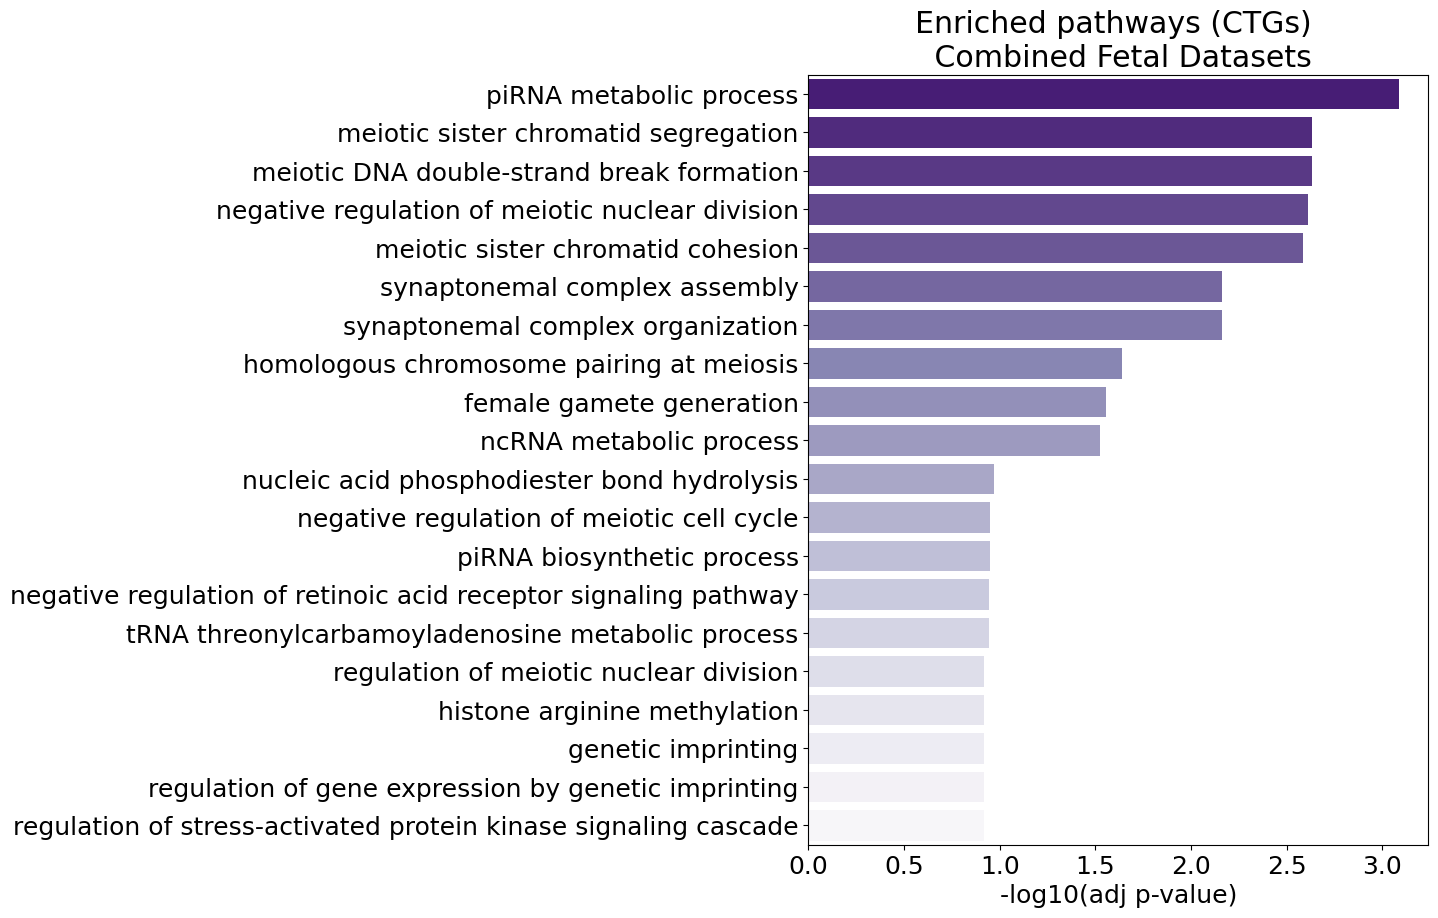

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns
import gseapy as gp

# run Enrichr
enr = gp.enrichr(gene_list=gene_order,gene_sets=["GO_Biological_Process_2021",],organism="Human", outdir=None)

# get results
results = enr.results
sig = results[results["P-value"] < 0.05]


# sort
sig = sig.sort_values("Combined Score")

# print top pathways
print(sig[["Term", "P-value", "Combined Score"]].head(15))


# take top pathways (already sorted by adjusted p-value ideally)
top = results.sort_values("Adjusted P-value").head(20)

# shorten names (optional but helps)
top["Term"] = top["Term"].str.replace(r"\s*\(GO:.*\)", "", regex=True)

plt.figure(figsize = (8,10))
palette = sns.color_palette("Purples",  n_colors=len(top))[::-1]

sns.barplot(
    data=top,
    x=-np.log10(top["Adjusted P-value"]),
    y="Term",
    palette=palette
)

plt.xlabel("-log10(adj p-value)")
plt.ylabel("")
plt.title("Enriched pathways (CTGs) \n Combined Fetal Datasets")
#plt.tight_layout()
plt.savefig("Combined Fetal Datasets.png", dpi=300)
plt.show()

In [64]:
top[["Term", "Genes"]]

,Term,Genes
0,piRNA metabolic process,TDRD1;MAEL;TEX15
1,meiotic sister chromatid segregation,HORMAD2;HORMAD1
2,meiotic DNA double-strand break formation,SPO11;HORMAD1
3,negative regulation of meiotic nuclear division,DMRT1;HORMAD1
4,meiotic sister chromatid cohesion,HORMAD2;HORMAD1
5,synaptonemal complex assembly,SYCP1;HORMAD1
6,synaptonemal complex organization,SYCP1;HORMAD1
7,homologous chromosome pairing at meiosis,SYCP1;HORMAD1
8,female gamete generation,SPO11;HORMAD1
9,ncRNA metabolic process,TDRD1;MAEL
